# Multiple Linear Regression: Predict House Price with MSE Evaluation

This notebook implements multiple linear regression to predict house prices based on three features: square footage (area), number of bedrooms, and age of the house. It emphasizes Mean Squared Error (MSE) for evaluation. The notebook includes: Problem Statement, Understanding of Dataset, Theory, Math, Workflow Diagram, Pseudocode, Expected/Obtained Output. Implementation includes data cleaning, EDA, feature scaling, feature engineering, and comprehensive evaluation metrics.

**Note:** If you receive a different CSV in the exam, change the `DATA_PATH`, `FEATURE_COLS`, and `TARGET_COL` variables in the imports cell accordingly.

In [1]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Change these if your exam CSV uses different column names
DATA_PATH = "house_prices.csv"
FEATURE_COLS = ["area", "bedrooms", "age"]
TARGET_COL = "price"

# Create synthetic dataset and save to CSV if it doesn't exist
if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 200
    area = np.round(np.random.uniform(500, 3500, n), 2)
    bedrooms = np.random.randint(1, 6, n)
    age = np.random.randint(0, 50, n)
    price = 50*area + 20000*bedrooms - 500*age + np.random.normal(0, 5000, n)
    price = np.clip(price, 50000, 500000)
    df_sample = pd.DataFrame({"area": area, "bedrooms": bedrooms, "age": age, TARGET_COL: price})
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Sample CSV created: house_prices.csv with 200 samples

First 5 rows of house_prices.csv:
      area  bedrooms  age          price
0  1623.62         4   32  134561.521378
1  3352.14         3   39  205478.224892
2  2695.98         1    9  146503.336692
3  2295.98         4   42  174550.968932
4   968.06         4   43  108611.779879


## 1. Problem Statement

**Objective:** Build a multiple linear regression model to predict house prices based on three features:
- **Area** (sq ft): Size of the house
- **Bedrooms**: Number of bedrooms
- **Age** (years): Age of the house

**Expected Output:** A trained model with predictions on test data and performance metrics including MSE, RMSE, MAE, and R² score.

## 2. Understanding of Dataset

Load the CSV file and display basic information about the dataset.

In [2]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn names and data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

DATASET OVERVIEW

First 10 rows:
      area  bedrooms  age          price
0  1623.62         4   32  134561.521378
1  3352.14         3   39  205478.224892
2  2695.98         1    9  146503.336692
3  2295.98         4   42  174550.968932
4   968.06         4   43  108611.779879
5   967.98         3   28  103779.854196
6   674.25         1   12   52464.619191
7  3098.53         3   11  206541.981722
8  2303.35         1   30  115675.426643
9  2624.22         5   45  211170.595858

Dataset shape: (200, 4)
Samples: 200, Features: 4

Column names and data types:
area        float64
bedrooms      int64
age           int64
price       float64
dtype: object

Statistical Summary:
          count           mean           std       min           25%  \
area      200.0    1952.018650    884.674190    516.57    1185.74500   
bedrooms  200.0       3.035000      1.440189      1.00       2.00000   
age       200.0      25.185000     14.101597      0.00      12.00000   
price     200.0  145354.558392 

## 3. Data Cleaning

Check for and handle missing values, duplicates, and invalid values.

In [3]:
print("="*60)
print("DATA CLEANING")
print("="*60)

# Check for missing values
print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"   Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    df = df.dropna()

# Check for duplicates
print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"   Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"   × Removed {dupes} duplicate(s)")
else:
    print("   ✓ No duplicates found")

# Check for invalid values
print("\n3. Invalid Values Check:")
invalid_area = (df["area"] < 0).sum()
invalid_beds = (df["bedrooms"] < 0).sum()
invalid_age = (df["age"] < 0).sum()
invalid_price = (df[TARGET_COL] < 0).sum()
print(f"   Invalid area: {invalid_area}")
print(f"   Invalid bedrooms: {invalid_beds}")
print(f"   Invalid age: {invalid_age}")
print(f"   Invalid price: {invalid_price}")

df = df[(df["area"] > 0) & (df["bedrooms"] > 0) & (df["age"] >= 0) & (df[TARGET_COL] > 0)]
df = df.reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
   Missing values per column:
area        0
bedrooms    0
age         0
price       0
dtype: int64
   ✓ No missing values found

2. Duplicate Rows Check:
   Duplicate rows: 0
   ✓ No duplicates found

3. Invalid Values Check:
   Invalid area: 0
   Invalid bedrooms: 0
   Invalid age: 0
   Invalid price: 0

Dataset shape after cleaning: (200, 4)


## 4. Exploratory Data Analysis (EDA)

Visualize relationships between features and the target price.

EXPLORATORY DATA ANALYSIS

Correlation Matrix:
              area  bedrooms       age     price
area      1.000000 -0.098296 -0.009845  0.824569
bedrooms -0.098296  1.000000  0.111025  0.457500
age      -0.009845  0.111025  1.000000 -0.078044
price     0.824569  0.457500 -0.078044  1.000000


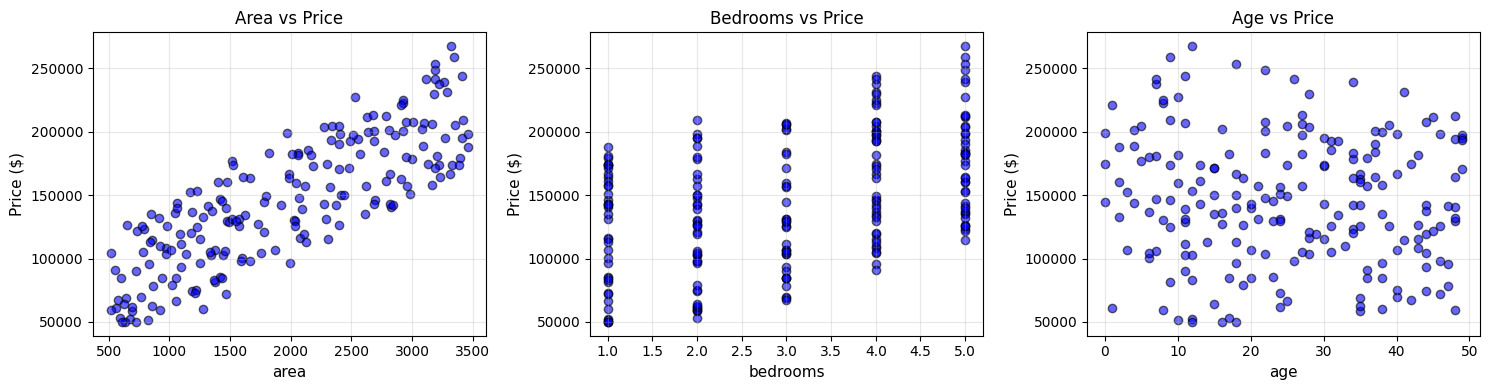

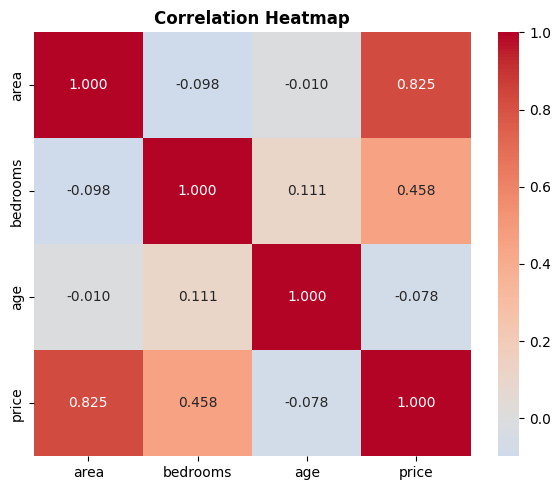


Correlations with Price:
  area: 0.8246
  bedrooms: 0.4575
  age: -0.0780


In [4]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Correlation matrix
corr_matrix = df[FEATURE_COLS + [TARGET_COL]].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Scatter plots for each feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(FEATURE_COLS):
    axes[idx].scatter(df[col], df[TARGET_COL], alpha=0.6, color='blue', edgecolors='black')
    axes[idx].set_xlabel(col, fontsize=11)
    axes[idx].set_ylabel('Price ($)', fontsize=11)
    axes[idx].set_title(f'{col.capitalize()} vs Price', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCorrelations with Price:")
for col in FEATURE_COLS:
    corr_val = df[col].corr(df[TARGET_COL])
    print(f"  {col}: {corr_val:.4f}")

## 5. Feature Engineering & Scaling

Prepare features and normalize using StandardScaler.

In [5]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

# Extract features and target
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"\nFeature matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nOriginal X (first 5 rows):")
print(X[:5])
print(f"\nScaled X (first 5 rows):")
print(X_scaled[:5])

print(f"\nScaler mean: {scaler.mean_}")
print(f"Scaler scale (std): {scaler.scale_}")

FEATURE ENGINEERING & SCALING

Feature matrix (X) shape: (200, 3)
Target vector (y) shape: (200,)
Number of features: 3

Original X (first 5 rows):
[[1.62362e+03 4.00000e+00 3.20000e+01]
 [3.35214e+03 3.00000e+00 3.90000e+01]
 [2.69598e+03 1.00000e+00 9.00000e+00]
 [2.29598e+03 4.00000e+00 4.20000e+01]
 [9.68060e+02 4.00000e+00 4.30000e+01]]

Scaled X (first 5 rows):
[[-0.3721401   0.67173216  0.48449133]
 [ 1.58661217 -0.02436334  0.98213466]
 [ 0.84305416 -1.41655434 -1.15062247]
 [ 0.38977569  0.67173216  1.19541037]
 [-1.11501819  0.67173216  1.26650227]]

Scaler mean: [1952.01865    3.035     25.185  ]
Scaler scale (std): [882.45973263   1.43658449  14.06629926]


## 6. Theory: Multiple Linear Regression

Multiple Linear Regression extends simple linear regression to use multiple input features to predict a continuous target variable.

**Equation:** y = β₀ + β₁x₁ + β₂x₂ + β₃x₃ + ... + βₙxₙ
- β₀ = intercept (bias term)
- β₁, β₂, ..., βₙ = coefficients (weights) for each feature
- x₁, x₂, ..., xₙ = input features

The model minimizes **Mean Squared Error (MSE)** to find optimal coefficients:

**MSE = (1/n) × Σ(yᵢ - ŷᵢ)²**

Where:
- n = number of samples
- yᵢ = actual value
- ŷᵢ = predicted value

## 7. Workflow Diagram

WORKFLOW DIAGRAM


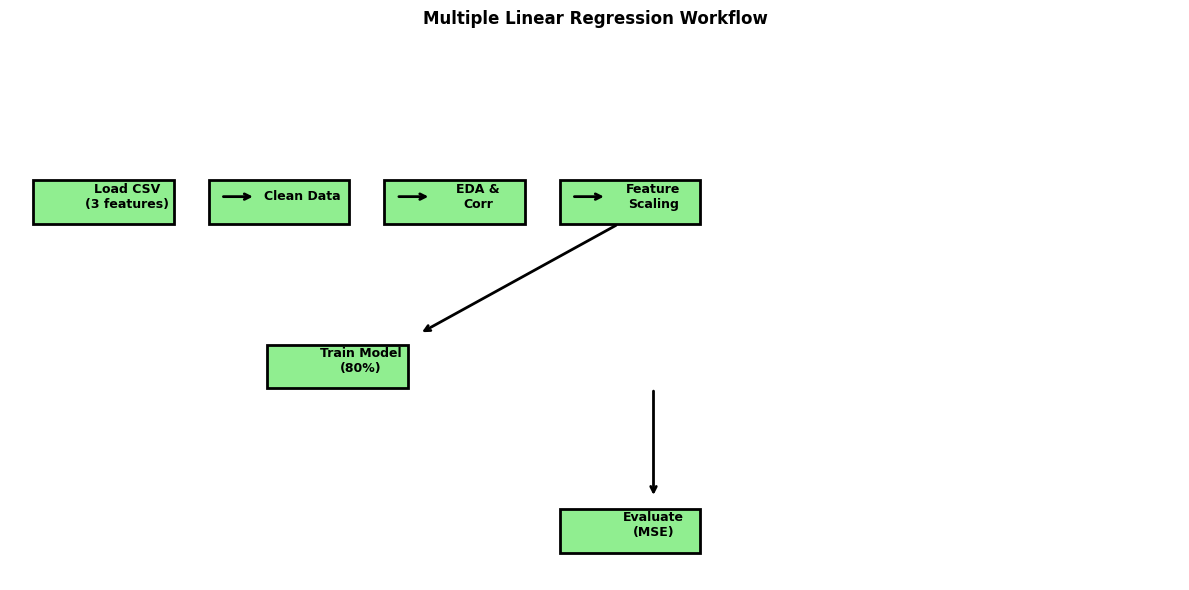

In [6]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV\n(3 features)"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA &\nCorr"),
    (0.55, 0.7, "Feature\nScaling"),
    (0.3, 0.4, "Train Model\n(80%)"),
    (0.55, 0.1, "Evaluate\n(MSE)"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x-0.08, step_y-0.05), 0.12, 0.08, 
                      facecolor='lightgreen', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

# Arrows
arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)),
          ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Multiple Linear Regression Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Pseudocode

```
ALGORITHM: Multiple Linear Regression

INPUT: DataFrame with features (area, bedrooms, age) and target (price)
OUTPUT: Trained model, predictions, and MSE evaluation

1. Load CSV file
2. Clean data (remove missing values, duplicates, outliers)
3. Extract features X and target y
4. Split data: 80% train, 20% test
5. Scale features using StandardScaler
6. Initialize LinearRegression model
7. Train model on training data: model.fit(X_train, y_train)
8. Make predictions on test data: y_pred = model.predict(X_test)
9. Calculate MSE = mean((y_test - y_pred)²)
10. Calculate RMSE, MAE, R² for evaluation
11. Save model and scaler for deployment
12. Visualize actual vs predicted values
```

## 9. Train-Test Split and Model Training

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Features per sample: {X_train.shape[1]}")

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nModel trained successfully!")
print(f"\nLearned Coefficients (β):")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {col}: {model.coef_[i]:.4f}")
print(f"Intercept (β₀): {model.intercept_:.2f}")

TRAIN-TEST SPLIT AND MODEL TRAINING

Train set size: 160 samples
Test set size: 40 samples
Features per sample: 3

Model trained successfully!

Learned Coefficients (β):
  area: 44552.5205
  bedrooms: 28224.3105
  age: -6651.8326
Intercept (β₀): 145549.99


## 10. Model Evaluation - MSE Focus

In [8]:
print("="*60)
print("MODEL EVALUATION - MSE EMPHASIS")
print("="*60)

# Predictions
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)

# Metrics
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nTraining Set Metrics:")
print(f"  MSE (Train): {mse_train:,.2f}")

print("\nTest Set Evaluation Metrics:")
print(f"  MSE (Mean Squared Error):   {mse_test:,.2f}")
print(f"  RMSE (Root Mean Squared):   {rmse_test:,.2f}")
print(f"  MAE (Mean Absolute Error):  {mae_test:,.2f}")
print(f"  R² Score:                   {r2_test:.4f}")

if r2_test > 0.9:
    print(f"\n✓ Excellent fit! Model explains {r2_test*100:.1f}% of variance")
elif r2_test > 0.7:
    print(f"\n✓ Good fit! Model explains {r2_test*100:.1f}% of variance")

# Sample predictions
print("\nSample Predictions (first 10 test samples):")
print(f"{'Actual':<15} {'Predicted':<15} {'Error':<15}")
print("-"*45)
for i in range(min(10, len(y_test))):
    error = abs(y_test[i] - y_pred[i])
    print(f"{y_test[i]:<15.2f} {y_pred[i]:<15.2f} {error:<15.2f}")

MODEL EVALUATION - MSE EMPHASIS

Training Set Metrics:
  MSE (Train): 26,736,391.31

Test Set Evaluation Metrics:
  MSE (Mean Squared Error):   23,334,869.89
  RMSE (Root Mean Squared):   4,830.62
  MAE (Mean Absolute Error):  4,103.37
  R² Score:                   0.9914

✓ Excellent fit! Model explains 99.1% of variance

Sample Predictions (first 10 test samples):
Actual          Predicted       Error          
---------------------------------------------
163625.75       161823.49       1802.26        
66779.86        60126.82        6653.04        
156460.93       164133.69       7672.76        
72823.96        68813.91        4010.05        
104395.28       101327.05       3068.24        
241767.31       242454.42       687.11         
197808.71       194376.04       3432.67        
227473.41       220653.05       6820.36        
150337.97       153023.67       2685.70        
192308.76       188797.55       3511.21        


## 11. Visualizations and Model Save

OBTAINED OUTPUT - VISUALIZATIONS


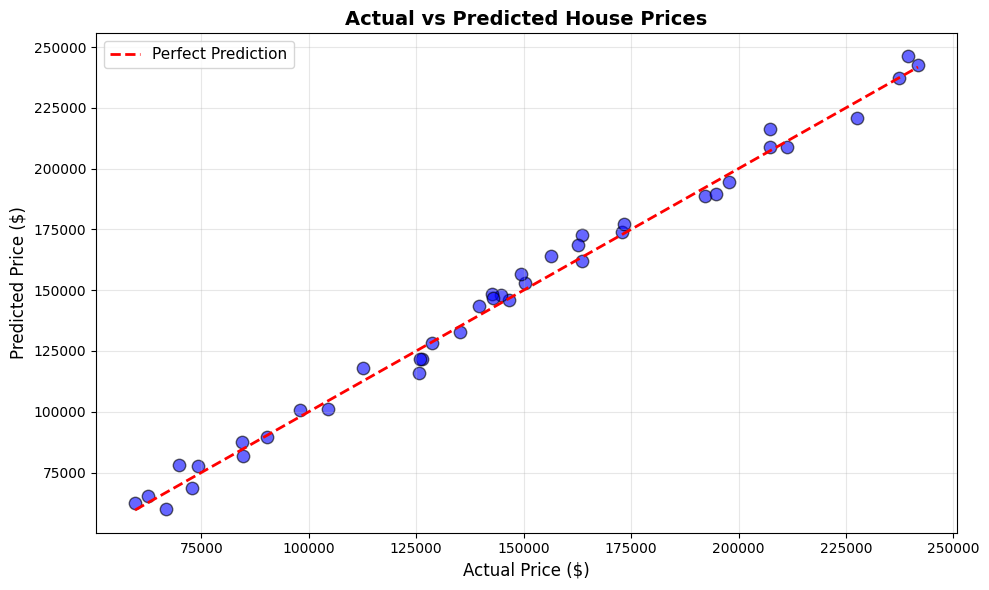

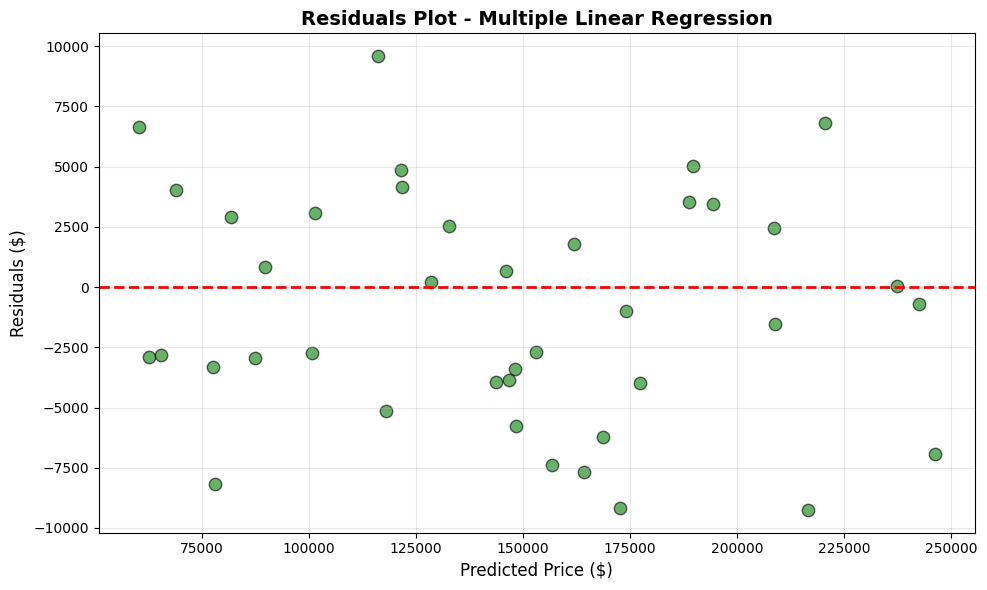

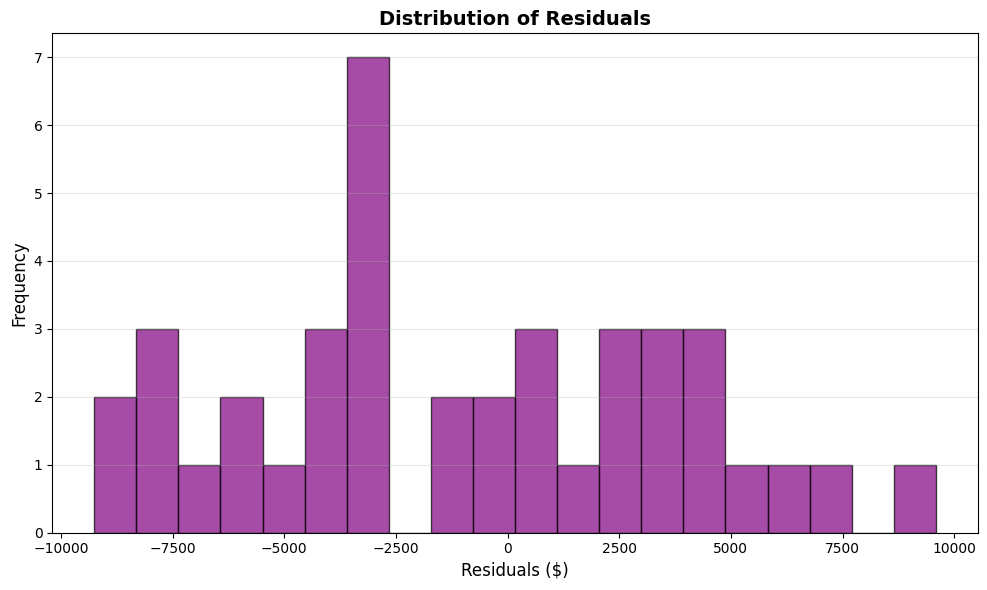


✓ Model and scaler saved successfully

FINAL SUMMARY
  Features Used: area, bedrooms, age
  Training Samples: 160
  Test Samples: 40
  MSE (Test): 23,334,869.89
  RMSE (Test): 4,830.62
  R² Score: 0.9914


In [9]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', s=80, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='green', s=80, edgecolors='black')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residuals Plot - Multiple Linear Regression', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Residuals ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Save model and scaler
joblib.dump(model, '3_mlr_model.joblib')
joblib.dump(scaler, '3_mlr_scaler.joblib')
print("\n✓ Model and scaler saved successfully")

print(f"\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Features Used: {', '.join(FEATURE_COLS)}")
print(f"  Training Samples: {X_train.shape[0]}")
print(f"  Test Samples: {X_test.shape[0]}")
print(f"  MSE (Test): {mse_test:,.2f}")
print(f"  RMSE (Test): {rmse_test:,.2f}")
print(f"  R² Score: {r2_test:.4f}")
print("="*60)